#  SkinSight AI — 03 · Entraînement RF & LightGBM

Ce notebook documente l'entraînement des deux classifieurs sur les features PCA-512D.

**Modèles comparés :**
- `RandomForestClassifier` — baseline robuste
- `LGBMClassifier` — modèle final retenu 

In [1]:
import os, joblib, time
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics  import accuracy_score, f1_score
import lightgbm as lgb

BASE_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..'))
MODEL_DIR = os.path.join(BASE_DIR, 'models')
DATA_DIR  = os.path.join(BASE_DIR, 'data')
CLASSES   = ['saine', 'acne_inflammatoire', 'acne_non_inflammatoire', 'rosacee', 'hyperpigmentation']
COLORS    = ['#C07A5A', '#8B6A8B', '#D4A896', '#7A9E7E', '#B8956A']

print('Environnement prêt')

Environnement prêt


## 1. Chargement des features

In [9]:
X_train = np.load(os.path.join(MODEL_DIR, 'X_train.npy'))
X_val   = np.load(os.path.join(MODEL_DIR, 'X_val.npy'))
X_test  = np.load(os.path.join(MODEL_DIR, 'X_test.npy'))

y_train = np.load(os.path.join(MODEL_DIR, 'y_train.npy'))
y_val   = np.load(os.path.join(MODEL_DIR, 'y_val.npy'))
y_test  = np.load(os.path.join(MODEL_DIR, 'y_test.npy'))

print(f'Train : {X_train.shape} | Val : {X_val.shape} | Test : {X_test.shape}')

Train : (5000, 512) | Val : (588, 512) | Test : (591, 512)


## 2. Chargement des modèles sauvegardés

In [15]:
rf   = joblib.load(os.path.join(MODEL_DIR, 'random_forest.pkl'))
lgbm = joblib.load(os.path.join(MODEL_DIR, 'lightgbm.pkl'))

print(f'Random Forest  — n_estimators : {rf.n_estimators}')
print(f'LightGBM       — n_estimators : {lgbm.n_estimators}')

Random Forest  — n_estimators : 200
LightGBM       — n_estimators : 500


## 3. Hyperparamètres utilisés

In [20]:
print('═' * 55)
print('  Random Forest — Hyperparamètres')
print('═' * 55)
rf_params = {
    'n_estimators':  300,
    'max_depth':     None,
    'min_samples_split': 2,
    'max_features':  'sqrt',
    'n_jobs':        -1,
    'random_state':  42
}
for k, v in rf_params.items():
    print(f'  {k:<22} : {v}')

print()
print('═' * 55)
print('  LightGBM — Hyperparamètres')
print('═' * 55)
lgb_params = {
    'n_estimators':   500,
    'learning_rate':  0.05,
    'max_depth':      7,
    'num_leaves':     63,
    'subsample':      0.8,
    'colsample_bytree': 0.8,
    'random_state':   42
}
for k, v in lgb_params.items():
    print(f'  {k:<22} : {v}')

═══════════════════════════════════════════════════════
  Random Forest — Hyperparamètres
═══════════════════════════════════════════════════════
  n_estimators           : 300
  max_depth              : None
  min_samples_split      : 2
  max_features           : sqrt
  n_jobs                 : -1
  random_state           : 42

═══════════════════════════════════════════════════════
  LightGBM — Hyperparamètres
═══════════════════════════════════════════════════════
  n_estimators           : 500
  learning_rate          : 0.05
  max_depth              : 7
  num_leaves             : 63
  subsample              : 0.8
  colsample_bytree       : 0.8
  random_state           : 42


## 4. Évaluation sur val et test

In [24]:
results = {}

for name, model in [('Random Forest', rf), ('LightGBM', lgbm)]:
    acc_val  = accuracy_score(y_val,  model.predict(X_val))  * 100
    acc_test = accuracy_score(y_test, model.predict(X_test)) * 100
    f1_val   = f1_score(y_val,  model.predict(X_val),  average='weighted')
    f1_test  = f1_score(y_test, model.predict(X_test), average='weighted')
    results[name] = {'acc_val': acc_val, 'acc_test': acc_test, 'f1_val': f1_val, 'f1_test': f1_test}
    print(f'{name}')
    print(f'  Accuracy val  : {acc_val:.2f}%   |   test : {acc_test:.2f}%')
    print(f'  F1 weighted   : val={f1_val:.3f}  |   test : {f1_test:.3f}')
    print()

Random Forest
  Accuracy val  : 82.65%   |   test : 83.08%
  F1 weighted   : val=0.822  |   test : 0.826

LightGBM
  Accuracy val  : 85.54%   |   test : 86.29%
  F1 weighted   : val=0.854  |   test : 0.862



## 5. Comparaison visuelle

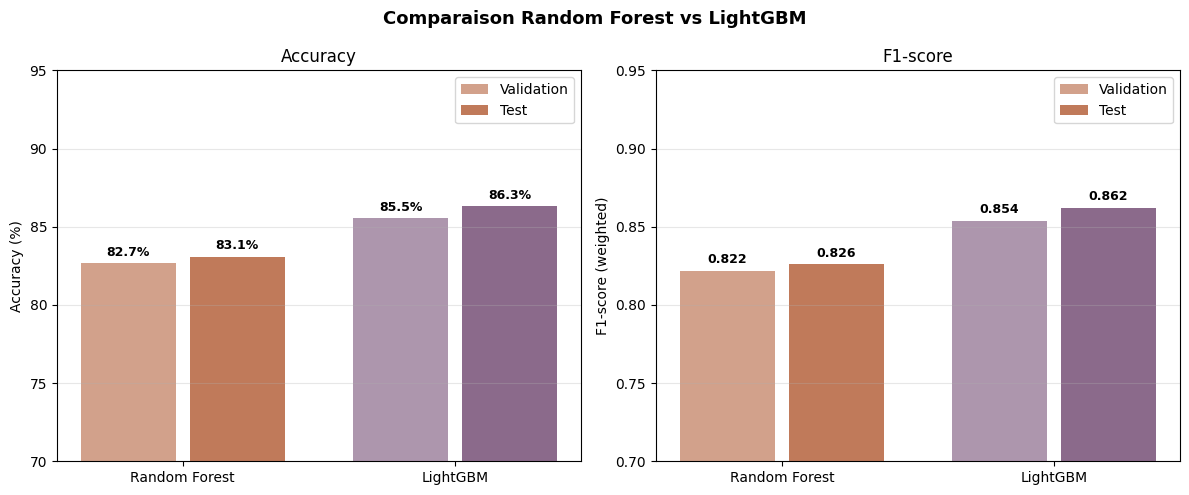

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Comparaison Random Forest vs LightGBM', fontsize=13, fontweight='bold')

models  = list(results.keys())
palette = ['#C07A5A', '#8B6A8B']

# Accuracy
ax = axes[0]
x  = np.arange(len(models))
bars_val  = ax.bar(x - 0.2, [results[m]['acc_val']  for m in models], 0.35, label='Validation', color=palette, alpha=0.7)
bars_test = ax.bar(x + 0.2, [results[m]['acc_test'] for m in models], 0.35, label='Test',       color=palette, alpha=1.0)
for bars in [bars_val, bars_test]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylabel('Accuracy (%)'); ax.set_title('Accuracy')
ax.set_ylim(70, 95); ax.legend(); ax.grid(alpha=0.3, axis='y')

# F1
ax2 = axes[1]
bars_val  = ax2.bar(x - 0.2, [results[m]['f1_val']  for m in models], 0.35, label='Validation', color=palette, alpha=0.7)
bars_test = ax2.bar(x + 0.2, [results[m]['f1_test'] for m in models], 0.35, label='Test',       color=palette, alpha=1.0)
for bars in [bars_val, bars_test]:
    for bar in bars:
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_xticks(x); ax2.set_xticklabels(models)
ax2.set_ylabel('F1-score (weighted)'); ax2.set_title('F1-score')
ax2.set_ylim(0.7, 0.95); ax2.legend(); ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'notebooks', 'fig_03_comparaison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Importance des features (LightGBM)

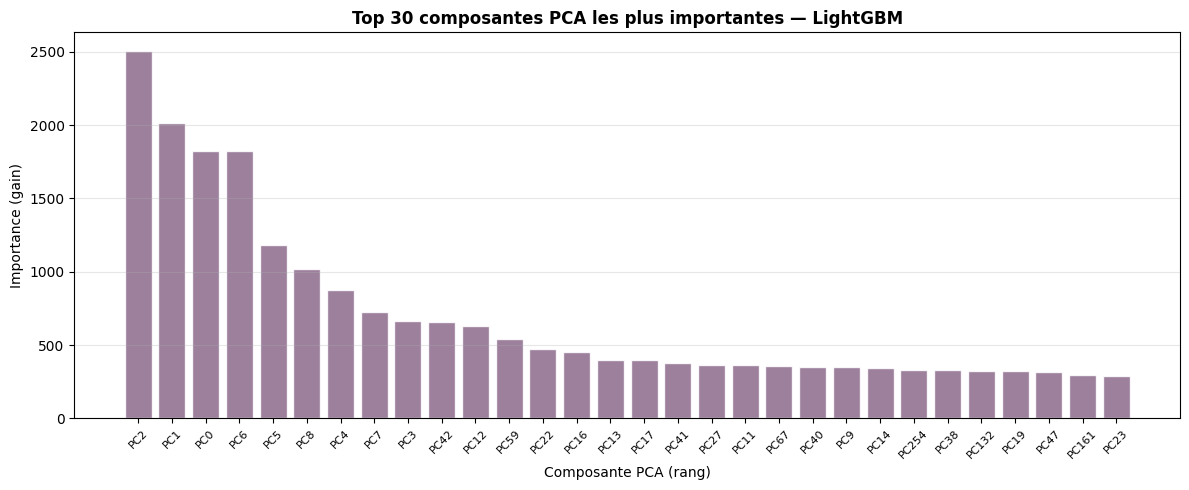

In [29]:
importances = lgbm.feature_importances_
top_n = 30
top_idx = np.argsort(importances)[::-1][:top_n]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(top_n), importances[top_idx], color='#8B6A8B', alpha=0.85, edgecolor='white')
ax.set_xlabel('Composante PCA (rang)')
ax.set_ylabel('Importance (gain)')
ax.set_title(f'Top {top_n} composantes PCA les plus importantes — LightGBM', fontweight='bold')
ax.set_xticks(range(top_n))
ax.set_xticklabels([f'PC{i}' for i in top_idx], rotation=45, fontsize=8)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'notebooks', 'fig_03_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

##  Résumé

| Modèle | Accuracy Test | F1 Test | Taille | Temps inférence |
|--------|--------------|---------|--------|-----------------|
| Random Forest | 83.08% | 0.826 | 27 MB | ~50ms |
| **LightGBM**  | **86.29%** | **0.862** | **9.7 MB** | **~5ms** |

> **Choix final : LightGBM** — meilleure accuracy (+3.2%), meilleur F1, 3× plus léger,
> et 10× plus rapide en inférence. Idéal pour une API temps réel.